
# <center> **Optimal Reverse Supply Chain**: </center>
## <center> Modeling Multi-Echelon, Multi-Indenture Systems </center>

# <br>
### Professor: Amanda Smith
### Project Members: Mitchell Stachowiak and Seth Ockerman
### University of Wisconsin - Madison
### Spring 2026

---
# <center>Introduction</center>

The project seeks to create a model that fulfills the demands of a reverse supply chain that is multi-echelon and multi-indenture using linear and integer optimization. Restated more concretely, this project develops a model to meet repair demand for aircraft that are composed of multiple components (e.g. engines, wheels) that each have their own sub-components (e.g. pistons, axles), where each sub-component also consists of smaller parts (e.g., screws, nuts, rivits). Our solution and report is organized into a series of progressive levels, beginning at level 0, where each increasing level systematically removes simplifying assumptions and introduces greater complexity.

Before we proceed, we define several key terms that will be used throughout this report. 



| Term | Definition |
|------|------------|
| Reverse Supply Chain | A system of processes that moves goods from the customer back to the producer, often enabling refurbishment, reuse, or redistribution before the goods are moved back to customers. Examples include refurbishment networks and product return systems. |
| Multi-echelon | a supply chain structure with multiple interconnected layers (e.g., supplier, warehouses, central hubs) through which goods flow before reaching the customer. |
| Multi-indenture | a hierarchical product structure composed of multiple levels of components and sub-components (e.g., assemblies, subassemblies, and parts). Decisions such as maintenance, repair, or inventory management must account for these dependencies across levels. |
| Line Replaceable Unit (LRU) [1] | A self-contained unit that can be replaced upon failure to restore system functionality (e.g. engine). LRUs represent the highest level in the multi-indenture system. |
| Shop Replaceable Unit (SRU) [1] | A sub-component of an LRU that is repaired or replaced in a maintenance facility (e.g. pistons, battery), sitting one level below LRUs in the multi-indenture hierarchy. |

### Problem Description
Our project considers aircraft repair logistics as a motivating example. Specifically, we study how to optimally repair aircraft using LRUs composed of multiple distinct SRUs, each of which is built from lower-level parts. These lower-level parts may be shared across SRUs or specialized to a single SRU, with specialized parts stocked only at designated locations. Below, we provide a simplified example of a multi-indenture product structure for clarity. 


> `*` marks a shared final-level part. `[S]` marks a specialized-only part.
> ```text
> LRU_1
> |-- SRU_1_1 x2
>    |-- PART_6* x2
>    `-- PART_13* x2
> `-- SRU_1_2 x2
>   |-- PART_7* x2
>   |-- PART_8*[S] x3

Repairs occur within a directed graph network (i.e. nodes which are connected via arcs) that exists in a standard Euclidean grid system. We utilize the following node types: customers, local repair shops, regional warehouses, central depots, and specialized shops. For simplicity, we divide our graph's x-axis into bands which proceed from left to right. We place customers in band 0, local shops in band 1, regional warehouses in band 3, central depots in band 4, and finally, specialized shops in band 5. The majority of our problem assumptions are embedded within the differences each node type, and as such, we describe each node type in-detail below. 

**Customers**  
Customer nodes generate demand for top-level LRUs in the reverse supply chain, with a hard-coded minimum demand of one item. Customers are connected only to nearby local shops, encoding the assumption that end users do not interact directly with warehouses, depots, or specialized facilities. In later model levels, we introduce the concept of time slices, where customers have different demands for each time slice representing demands over time.

**Local Shop**  
Local shops are small, nearby facilities that are directly connected to customers. They almost never carry LRUs, occasionally carry SRUs, and usually carry small quantities of low-level parts. By placing local shops between the customer and the regional warehouse, we encode the assumption that local shops serve as access points for intake and light service, rather than broad inventory hubs or high-end repair centers. Local shops have lower repair skill and modest cost, however, they complete repairs quicker than all but specialized shops. 

**Regional Warehouses**  
Regional warehouses stand between local shops and central depots or specialized shops. Our scripts assume they have moderate-to-high inventory breadth and depth, they commonly carry SRUs and parts, and occasionally carry LRUs. They have modest repair skill, cost, and time.

**Central Depot**  
Depots are the hubs of our network and have the largest and most diverse inventory. They contain a variety of SRUs and some LRUs, along with a wide range of basic parts. They are connected to regional warehouses and specialized shops. They are the cheapest option and have high skill, however, they are the slowest to complete repairs.

**Specialized Shops**  
Specialized shops stock fewer items overall, but they frequently stock SRUs and shared parts. Additionally, they contain specialized parts that can only be stocked at these locations. Specialized shops have the highest repair skill and complete skills the fastest, however, their repairs are the most expensive.


To make our problem structure concrete, we include a visualization of the network used for level 0 of this report. Note that all the level's graphs are very similar, but the specific location of the nodes changes slightly. 


![Graph](level0data/network_visualization_graph.png)



In summary, we model aircraft reverse supply chain operations with multi-echelon and multi-indenture repairs as a minimum-cost-network-flow-like problem, utilizing integeroptimization. Our model captures both flow decisions across the network and repair dependencies across indenture levels, which further constrain repair across the network by component availability. The goal of the model is to determine how to route and allocate LRUs/SRUs across the network, so that aircraft repair demand is fulfilled while respecting network constraints/component dependencies and minimizing cost.

### Historical Context and Problem Relevance
This project was inspired by the work of Craig C. Sherbrooke, in particular his work in developing marginal analysis tools such as the METRIC, as well as his textbook *Optimal Inventory Modeling of Systems: Multi-Echelon Techniques* [1]; however, we implement our models using linear programming methods rather than Sherbrooke's marginal approach. Moreover, while his work considered defense applications, our work generalizes to problems faced in the commercial sector such as commercial aviation or trucking, where the same low demand and high cost assumptions can be applied. In these areas, it is critical to prevent misallocation of demands and resources as turnarounds are usually slow, mistakes are costly, and inefficiencies can easily compound into other sectors (e.g. commerce, travel, defense).

Our project uses aircraft repair as a motivating example. Because aircraft are far less numerous than automobiles, a single out-of-service aircraft can have a disproportionately large impact on the economy and the flow of travel. At the same time, aircraft are highly specialized systems, and repairs are often both expensive and dependent on specialized parts. This creates a fundamental tradeoff: minimizing downtime may require costly or expedited repairs, while minimizing cost can prolong periods of inactivity. In some cases, repairing a more complex or expensive set of components may return an aircraft to service sooner than lower-cost alternatives that would otherwise be prioritized. This tradeoff makes the problem well-suited for optimization. By adjusting the relative weights of time and cost in the objective function, we can model and evaluate different repair and logistics strategies.

### Data Generation
This project uses a parameterized data generator to construct the network, costs, inventory levels, and other problem attributes using realistic (and adjustable) assumptions. While the generator is not the primary focus of this report, it is designed to be flexible so that others can tailor the data to their specific use cases. Through simple command-line parameters, users can control key aspects of the problem, such as the number of customers, the number and types of nodes (e.g., central depots and local shops), and the number of components used to construct LRUs and SRUs.We also provide visualization scripts that allow users to inspect both the generated network and resulting solutions, enabling intuitive analysis of the system behavior that we use throughout this report. To encode our assumptions in the data generator process, we introduce a set of parameters that control the likelihood of different node attributes. The below table summarizes the key values associated with each node type, and we include a list of simplifying assumptions.


| Node Type | Network Role | Inventory Role | Specialized-Only Parts | Repair Skill | Repair Capacity | Repair Cost Multiplier | Repair Time Multiplier | Demand Role | Main Encoded Assumption |
  |---|---|---|---|---|---|---:|---:|---|---|
  | customer | End user / demand source | No inventory | Cannot stock | 0 | 0 | none | none | Generates demand, only for top-level LRUs | Customers are non-repair, non-inventory endpoints that access the system only through local shops |
  | local_shop | Intake / light-service node | Mostly parts, tiny SRU presence, effectively no LRU stocking | Cannot stock | Low | Low | 1.20 | 0.95 | None | Fairly responsive, but limited in inventory depth, repair scope, and scale |
  | regional_warehouse | Mid-network generalist | Broad mixed inventory, moderate depth | Cannot stock | Low-to-mid | Medium | 1.00 | 1.10 | None | Balanced default option in the middle of the network |
  | central_depot | Deep stock / high-scale hub | Broadest and deepest inventory, including some LRUs | Cannot stock | High | Highest | 0.85 |3.0 | None | Economies of scale: cheapest and most capable, but slowest |
  | specialized_shop | Specialized repair node | Focused SRU/part inventory, no LRUs | Can stock | High | Medium | 2.0 | 0.80 | None | Premium fast specialist: high skill, narrow role, expensive, and necessary for specialized-only parts |


Simplifying Assumptions
* Each node has unlimited storage for parts and there is no storage cost.
* There exists a valid solution to fufill repair demand.
* Arcs have unlimited capacity and shipping cost is equal in both directions.

### Outline 

This report is organized as follows. As noted above, our approach divides the project into progressive levels, where each increase in level removes simplifying assumptions and introduces additional complexity. Our report present each level of our solution (Levels 0–3), with each level including its own "Math Model", "Implementation and Solution" and "Discussion of Results" sections. Finally, the "Conclusion"" section summarizes our findings and outlines directions for future work.

---
## <center>Package Managment</center>

To run the optimization models, as well as to read, write, and present the data, we import all required packages.

As our models will involve the use of many integer variables and constraints, we have choosen to use the comercial optimizer *Gurobi* [2] via an academic license in conjuntion with the Julia optimization framework JuMP.

In [2]:
# Include All Required Packages
import Pkg
Pkg.add(["JuMP", "Gurobi"], io=devnull)    # Optimization
Pkg.add(["DataFrames", "CSV"], io=devnull) # I/O
Pkg.add("Plots", io=devnull)               # Figures


# Gurobi File Locations & Build if Needed
# ENV["GUROBI_HOME"] = "C:\\Program Files\\gurobi1301\\win64"
# Pkg.build("Gurobi", io=devnull)


# Use All Required Packages
using JuMP, Gurobi    # Optimization
using DataFrames, CSV # I/O
using Plots           # Figures

---
# <center>Level 0: Math Model, Implementation, Results, and Discussion </center>

Level 0 serves as a minimum viable model that captures the proposed problem in a simplified setting. Demand is satisfied using complete LRUs; when an LRU is available, the only cost incurred is the shipping cost to the customer (i.e., the sum of costs along all traversed arcs). If demand cannot be met with available LRUs, SRUs and individual parts are used to repair LRUs at non-customer locations. Parts and SRUs are shipped as needed, and SRUs can be repaired at different locations than the LRU they are used to repair. The repaired LRUs are shipped to the customer when complete, and all non-customer nodes can complete any of the required repairs.

Each component can incur a repair cost when it is generated by a repiar or a transportation cost when transported across arcs (see `bom.csv` for repair cost details, as well as general repair details, and `edges.csv` for transportation costs). The objective of the model is to minimize the total cost of repairs and transportation while satisfying all demand.

### Math Model

Concisely, we want to determine how to transport components through the network and repair components within the network such that we minimize the total cost fulfilling customer demands.


We have the following problem data.

Let $N$ denote the set of nodes within the network (i.e. customers, shops, warehouses, depots);
let $A$ denote the set of arcs connecting these nodes (i.e. roads, shipping routes, flights) that components can be transported through;
and let $K$ denote the set of components including LRUs, SRUs, and parts.
In addition, let $d_{n, k} \geq 0$ denote the number of component $k \in K$ demanded at node $n \in N$;
let $I_{n, k} \geq 0$ denote the number of component $k \in K$ demanded at node $n \in N$;
let $K_{k} \subseteq K$ denote the set of components required to repair $k \in K$ with assoicated quantities $q_{k, k'} \geq 0$ of the subcomponent $k' \in K_{k}$;
let $C_{k}^{\text{repair}} \geq 0$ denote the standard cost of repairing component $k \in K$ and $C_{a}^{flow} \geq 0$ denote the standard cost of traversing arc $a \in A$.



We first declare our decision variables.

Let $x_{a, k} \in \mathbb{Z}$ denote the number of component $k \in K$ which are transported through arc $a \in A$;
let $r_{n, k} \in \mathbb{Z}$ denote the number of component $k \in K$ which are repaired at node $n \in N$.



We next construct our constraints.

We cannot have negative flow between nodes, nor can we have negative repairs at nodes; thus, we have the nonnegativity constraints,
$$
x_{a, k} \geq 0, \qquad a \in A,\ k \in K
$$
$$
r_{n, k} \geq 0. \qquad n \in N,\ k \in K
$$

We can only allow components to flow via the allowed pathways of transportation and repair, including their consumption for repair and existance as present inventory. As such, we have the slighly modified flow constraint from usual minumum cost network flow (MCNF) problems,
$$
I_{n, k} + \sum_{(i, n) \in A} x_{(i, n), k} + r_{n, k} \geq \sum_{(n, i) \in A} x_{(n, i), k} + \sum_{k' \in K_{k}} r_{n, k'}q_{k', k} + d_{n, k}, \qquad n \in N,\ k \in K
$$
which represents inventory + inflow + repair = outflow + consumed + demand. Unlike usual MCNF problems, we do not have equality. This is because, with equaltiy, all components would have to be used to fill demands; however, by letting this be this inequality, we allow for unused components to remain at nodes.



We lastly construct our objective function.

We want to minimize the cost of filling demands; thus, we want to minimize the cost of traversal,
$$
\sum_{a \in A, k \in K} C_{a}^{flow} x_{a, k},
$$
and we want to minimize the cost of repair,
$$
\sum_{n \in N, k \in K} C_{k}^{repair} r_{n, k},
$$
together; hence, we have the objective function we want to minimize as,
$$
\sum_{a \in A, k \in K} C_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} C_{k}^{repair} r_{n, k}.
$$



Putting this together, we have the integer linear program,
$$
\begin{align*}
    \min \quad 
    & \sum_{a \in A, k \in K} C_{a}^{\text{flow}} x_{a, k} + \sum_{n \in N, k \in K} C_{k}^{\text{repair}} r_{n, k} \\
    \text{s.t.} \quad
    & I_{n, k} + \sum_{(i, n) \in A} x_{(i, n), k} + r_{n, k} \geq \sum_{(n, i) \in A} x_{(n, i), k} + \sum_{k' \in K_{k}} r_{n, k'} q_{k', k} + d_{n, k}, 
        && n \in N,\ k \in K \\
    & x_{a, k} \geq 0, 
        && a \in A,\ k \in K \\
    & r_{n, k} \geq 0, 
        && n \in N,\ k \in K
\end{align*}
$$

### Implementation

We load in the Level 0 data from the relevant CSV files output from data generation, then converting the dataframes into convenient data-structures, like dictionaries and lists, which are used to implement the math model above using the JuMP framework.

In [3]:
# Load Data
node_df = CSV.read("level0data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level0data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level0data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level0data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level0data/node_inventory.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    node = Node(node_id, node_type, (x, y))
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes 


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node to nodes incident to the node
outgoing = Dict() # dictionary of node to nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end
# <center>Level 1: Math Model, Implementation, Results, and Discussion </center>

# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_cost::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    comp_id = bom_item.child_component_id
    comp_type = "part"
    comp_repair_cost = 0
    comp_repair_list = []
    comp = Component(comp_id, comp_type, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of (node, comp) -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of (node, comp) -> Demand struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end

We then directly implement the Level 0 math model using these data-structures.

In [4]:
# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints

## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end

## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp] for comp in components, arc in arcs) + # transport cost
           sum(BOM[comp].repair_cost * r[node, comp] for comp in components, node in nodes)   # repair cost
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


### Solution

In [5]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
mkpath("level0output")
CSV.write("level0output/flow_output.csv", flow_output_df)
CSV.write("level0output/repair_output.csv", repair_output_df);

Optimal Objective Value: 1402.0

Optimal Flow Schedule:
15×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_1      1
   2 │ LRU_2    DEPOT_1    REGWH_2      1
   3 │ LRU_2    LOCAL_2    CUST_2       2
   4 │ LRU_2    LOCAL_3    CUST_3       3
   5 │ LRU_2    LOCAL_4    CUST_4       1
   6 │ LRU_2    REGWH_1    LOCAL_2      2
   7 │ LRU_2    REGWH_2    LOCAL_3      3
   8 │ LRU_2    REGWH_2    LOCAL_4      1
   9 │ LRU_2    SPEC_1     REGWH_1      1
  10 │ LRU_2_2  DEPOT_1    REGWH_2      3
  11 │ LRU_3    LOCAL_2    CUST_3       2
  12 │ LRU_3    REGWH_1    LOCAL_2      2
  13 │ LRU_5    DEPOT_1    REGWH_1      3
  14 │ LRU_5    LOCAL_1    CUST_1       3
  15 │ LRU_5    REGWH_1    LOCAL_1      3

Optimal Repair Schedule:
5×3 DataFrame
 Row │ comp_id  node_id  qty   
     │ String   String   Int64 
─────┼─────────────────────────
   1 │ LRU_2    DEPOT_1      2
   

### Discussion

As shown in the figure below, level 0's solution shows a fairly simple sequence of events where the majority of repairs where performed at the central depot and only a single specialized repair is needed. As expected, the model avoids traversing the long edges when a shorter option is available, even if that might consist of traversing two edges. Due to the minimal constraints, we only need to repair LRUs, we do not need to use smaller sub-components to repair SRUs that are then used to repair SRUs.

![Graph](level0output/solution_network_all.png)

If we zoom in on specifically LRU_2 (shown below), we see that a sub-component SRU (shown as LRU_2_2) is shipped from the depot to REGWH_2, before it is repaired there and shipped to the customer. Per-component repair and movement visualizations are available in `level0output/solution_by_component`.

![Graph](level0output/solution_family_lru_2.png)

# <center>Level 1: Math Model, Implementation, Results, and Discussion </center>

Level 1 adds cost multipliers by location, so that some locations are more expensive to repair at than others. We also add repair difficultly, where some repairs require a certain level of skill to complete. Skill level varies by shop location, with the higher skill level nodes generally being more expensive. 

### Math Model 

We want to modify our Level 0 math model to include the extra logic of Level 1. Specifically, we want to add constraints preventing repairs of difficulty higher than the shops skill as well modify the objective function to account for repair cost multipliers by location.


We have the following additional problem data.

Let $N_{k} \subseteq N$ denote the set of nodes within the network for which component $k \in K$ can be repaired.
In addition, let $m_{n}^{\text{cost}} \geq 0$ denote the repair cost multiplier at node $n \in N$.



We have no additional decision variables to declare.



We next construct the following additional constraints.

We cannot repair components of difficulty greater than the shops capability,
$$
r_{n, k} = 0. \qquad n \in N \setminus N_{k},\ k \in K
$$



We lastly modify our objective function.

We apply our repair cost multiplier to the repair cost,
$$
\sum_{n \in N, k \in K} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k};
$$
hence, we have the objective function we want to minimize as,
$$
\sum_{a \in A, k \in K} C_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k}.
$$



Putting this together, we have the integer linear program,
$$
\begin{align*}
    \min \quad 
    & \sum_{a \in A, k \in K} C_{a}^{\text{flow}} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k} \\
    \text{s.t.} \quad
    & I_{n, k} + \sum_{(i, n) \in A} x_{(i, n), k} + r_{n, k} \geq \sum_{(n, i) \in A} x_{(n, i), k} + \sum_{k' \in K_{k}} r_{n, k'} q_{k', k} + d_{n, k},
        && n \in N,\ k \in K \\
    & r_{n, k} = 0,
        && n \in N \setminus N_{k},\ k \in K \\
    & x_{a, k} \geq 0, 
        && a \in A,\ k \in K \\
    & r_{n, k} \geq 0, 
        && n \in N,\ k \in K
\end{align*}
$$

### Implementation

Similarly, we load in the Level 1 data.

In [8]:
# Load Data
node_df = CSV.read("level1data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level1data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level1data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level1data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level1data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level1data/component_multiplier.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    node = Node(node_id, node_type, (x, y), repair_capability)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes 


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_difficulty::Int
    repair_cost::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_difficulty = bom_item.parent_component_repair_difficulty
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_difficulty, comp_repair_cost, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    part_id = bom_item.child_component_id
    part_type = "part"
    part_repair_difficulty = 0
    part_repair_cost = 0
    part_repair_list = []
    part = Component(part_id, part_type, part_repair_difficulty, part_repair_cost, part_repair_list)
    BOM[part_id] = part
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of (node, comp) -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of (node, comp) -> Demand struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
end
mult_dict = Dict() # dictionary of (node, comp) -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier
    mults = Mults(mults_node, mults_comp, repair_cost_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end


We then directly implement the Level 1.

In [9]:
# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints
## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if BOM[comp].repair_difficulty > node_dict[node].repair_capability
        @constraint(m, r[node, comp] == 0)
    end
end


# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp]
           for comp in components, arc in arcs) + # transport cost
           sum(get(mult_dict, (node, comp), Mults("", "", 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp] # repair cost multipliers
           for comp in components, node in nodes) # repair cost
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


### Results 

In [10]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
mkpath("level1output")
CSV.write("level1output/flow_output.csv", flow_output_df)
CSV.write("level1output/repair_output.csv", repair_output_df);

Optimal Objective Value: 1434.3

Optimal Flow Schedule:
15×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_1      2
   2 │ LRU_2    DEPOT_1    REGWH_2      4
   3 │ LRU_2    LOCAL_2    CUST_2       2
   4 │ LRU_2    LOCAL_3    CUST_3       3
   5 │ LRU_2    LOCAL_4    CUST_4       1
   6 │ LRU_2    REGWH_1    LOCAL_2      2
   7 │ LRU_2    REGWH_2    LOCAL_3      3
   8 │ LRU_2    REGWH_2    LOCAL_4      1
   9 │ LRU_2_1  SPEC_4     DEPOT_1      1
  10 │ LRU_3    DEPOT_1    REGWH_2      2
  11 │ LRU_3    LOCAL_3    CUST_3       2
  12 │ LRU_3    REGWH_2    LOCAL_3      2
  13 │ LRU_5    DEPOT_1    REGWH_1      3
  14 │ LRU_5    LOCAL_1    CUST_1       3
  15 │ LRU_5    REGWH_1    LOCAL_1      3

Optimal Repair Schedule:
3×3 DataFrame
 Row │ comp_id  node_id  qty   
     │ String   String   Int64 
─────┼─────────────────────────
   1 │ LRU_2    DEPOT_1      6
   

### Discussion

As shown in the figure below, level 1's represents an extreme, where all the repairs are performed at the central depot. This is expected behavior, as the depot is the cheapest of the repair options, and its high skill level allows it to complete the vast majority of repairs. However, this solution breaks down under real-world conditions, as the depot would become backlogged (this limitation is addressed in level 2) and slow down repairs. However, under cost minimization assumptions that do not factor in time, solely utilizing the central depot is the best option.

![Graph](level1output/solution_network_all.png)

# <center>Level 2: Math Model, Implementation, Results, and Discussion </center>

Level 2 introduces the notion of time into our model. Specifically, each part now requires a certain amount of time to repair, different locations have different repair speeds represented as multipliers to the component repair time, and arcs have a time cost. We introduce a time-cost into the objective function, with a weight variable that allows us to test different speed/cost trade-offs. Additionally, we introduce the idea of location hours, meaning that each node can only repair so many items. These additions address many of the limitations of the previous levels by incorporating both the notion of time cost and a limited capacity for each node.

### Math Model

We want to modify our Level 1 math model to include the extra logic of Level 2. Specifically, we want to modify the objective function to include the transport time and repair time, with multipliers, as a tradeoff with the weight parameter $\lambda^{\text{time}}$; additionally, we want to provide an upper bound on repairs at each location (e.g. shop-hours per day).


We have the following additional problem data.

Let $T_{k}^{\text{repair}}$ denote the standard time it takes to repair component $k \in K$ and let $T_{a}^{\text{flow}}$ denote the standard time it takes to traverse arc $a \in A$;
let $m_{n}^{\text{time}} \geq 0$ denote the repair time multiplier at node $n \in N$;
let $T_{n}^{\text{cap}} \geq 0$ denote the node's $n \in N$ time shop capcacity.



We have no additional decision variables to declare.



We next construct the following additional constraints.

Repairs at a node cannot exceed that nodes work-hour shop capacity,
$$
\sum_{k \in K} m_{n}^{\text{time}} T_{k}^{\text{repair}} r_{n, k} \leq T_{n}^{\text{cap}}. \qquad n \in N
$$



We lastly modify our objective function.

We want to minimize the time of filling demands; thus, we want to minimize the time of traversal,
$$
\sum_{a \in A, k \in K} T_{a}^{flow} x_{a, k},
$$
and we want to minimize the cost of repair,
$$
\sum_{n \in N, k \in K} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k},
$$
together which gives us our time portion to the objective function,
$$
\sum_{a \in A, k \in K} T_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k};
$$
hence, with the trade-off weight parameter $\lambda^{\text{time}}$, we have the objective function we want to minimize as,
$$
\left( \sum_{a \in A, k \in K} C_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k} \right) +
\lambda^{\text{time}}\left( \sum_{a \in A, k \in K} T_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k} \right).
$$



Putting this together, we have the integer linear program,
$$
\begin{align*}
    \min \quad 
    & \left( \sum_{a \in A, k \in K} C_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k} \right) + \\
\lambda^{\text{time}} & \left( \sum_{a \in A, k \in K} T_{a}^{flow} x_{a, k} + \sum_{n \in N, k \in K} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k} \right) \\
    \text{s.t.} \quad
    & I_{n, k} + \sum_{(i, n) \in A} x_{(i, n), k} + r_{n, k} \geq \sum_{(n, i) \in A} x_{(n, i), k} + \sum_{k' \in K_{k}} r_{n, k'} q_{k', k} + d_{n, k},
        && n \in N,\ k \in K \\
    & r_{n, k} = 0,
        && n \in N \setminus N_{k},\ k \in K \\
    & \sum_{k \in K} m_{n}^{\text{time}} T_{k}^{\text{repair}} r_{n, k} \leq T_{n}^{\text{cap}},
        && n \in N \\
    & x_{a, k} \geq 0, 
        && a \in A,\ k \in K \\
    & r_{n, k} \geq 0, 
        && n \in N,\ k \in K
\end{align*}
$$

### Implementation

Similarly, we load in the Level 2 data.

In [21]:

# Load Data
node_df = CSV.read("level2data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level2data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level2data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level2data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level2data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level2data/component_multiplier.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
    repair_capacity::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    repair_capacity = df_node.repair_capacity
    node = Node(node_id, node_type, (x, y), repair_capability, repair_capacity)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
    trans_time::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    trans_time = df_arc.time_cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost, trans_time)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_difficulty::Int
    repair_cost::Float64
    repair_time::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_difficulty = bom_item.parent_component_repair_difficulty
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_time = bom_item.parent_component_repair_time
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_difficulty, comp_repair_cost, comp_repair_time, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    part_id = bom_item.child_component_id
    part_type = "part"
    part_repair_difficulty = 0
    part_repair_cost = 0
    part_repair_time = 0
    part_repair_list = []
    part = Component(part_id, part_type, part_repair_difficulty, part_repair_cost, part_repair_time, part_repair_list)
    BOM[part_id] = part
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    qty::Int
end
demands = Dict() # dictionary of each node and component pair -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    qty = df_demand.quantity
    demand = Demand(demand_id, demand_node, demand_comp, qty)
    demands[(demand_node, demand_comp)] = demand
end


# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of each node and component pair -> Stock struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
    repair_time_mult::Float64
end
mult_dict = Dict() # dictionary of each location and component -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier # change column name to repair_cost_mult
    repair_time_mult = df_mults.repair_time_multiplier # change column name to repair_time_mult
    mults = Mults(mults_node, mults_comp, repair_cost_mult, repair_time_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end


We then directly implement the Level 2.

In [22]:
# Parameter
lambda_time = 1 # lambda parameter


# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
@variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node


# Constraints
## Flow Conservation
for comp in components, node in nodes
    inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
    outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
    demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
    stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
    repairs = r[node, comp]                                                   # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes
            @constraint(m, r[node, comp] == 0)
        end
    end
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if BOM[comp].repair_difficulty > node_dict[node].repair_capability
        @constraint(m, r[node, comp] == 0)
    end
end


## Limit Node Repairs to Repair Capacity Hours
for node in nodes
    @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult *
                BOM[comp].repair_time * r[node, comp] for comp in components) <= node_dict[node].repair_capacity)
end



# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp]
           for comp in components, arc in arcs) + # transport cost
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp]
           for comp in components, node in nodes) + # repair cost
           lambda_time * (sum(arc_dict[arc].trans_time * x[arc, comp]
           for comp in components, arc in arcs) + # transport time
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp]
           for comp in components, node in nodes)) # repair time
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


### Results

In [23]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs
    val = value(x[(node_from, node_to), comp])
    if val > 1e-3
        push!(flow_output_df, (comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes
    val = value(r[node, comp])
    if val > 1e-3
        push!(repair_output_df, (comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)


## Convert Output to CSV
mkpath("level2output")
CSV.write("level2output/flow_output.csv", flow_output_df)
CSV.write("level2output/repair_output.csv", repair_output_df);

Optimal Objective Value: 4302.5

Optimal Flow Schedule:
23×4 DataFrame
 Row │ comp_id  node_from  node_to  qty   
     │ String   String     String   Int64 
─────┼────────────────────────────────────
   1 │ LRU_2    DEPOT_1    REGWH_2      3
   2 │ LRU_2    LOCAL_1    CUST_2       2
   3 │ LRU_2    LOCAL_3    CUST_3       3
   4 │ LRU_2    LOCAL_4    CUST_4       1
   5 │ LRU_2    REGWH_1    LOCAL_1      2
   6 │ LRU_2    REGWH_2    LOCAL_3      3
   7 │ LRU_2    REGWH_2    LOCAL_4      1
   8 │ LRU_2    SPEC_1     REGWH_1      2
   9 │ LRU_2    SPEC_2     DEPOT_1      2
  10 │ LRU_2    SPEC_4     REGWH_2      1
  11 │ LRU_2_2  DEPOT_1    SPEC_2       2
  12 │ LRU_2_2  REGWH_1    SPEC_1       2
  13 │ LRU_2_2  REGWH_2    SPEC_4       1
  14 │ LRU_3    DEPOT_1    REGWH_2      2
  15 │ LRU_3    LOCAL_3    CUST_3       2
  16 │ LRU_3    REGWH_2    LOCAL_3      2
  17 │ LRU_3    SPEC_3     DEPOT_1      1
  18 │ LRU_3_1  DEPOT_1    SPEC_3       1
  19 │ LRU_5    DEPOT_1    REGWH_1      3
  

### Discussion

We first examine the solution under an objective that assigns equal weight to time and cost. We then perform a Pareto curve analysis to illustrate the tradeoffs between these two objectives.  

As shown in the figure below, incorporating time into the objective introduces more nuanced and realistic behavior. For example, some components are routed to specialized shops, which are more expensive but offer faster repair times, before being shipped back to central depot or regional warehouses and ultimately delivered to the customer. In contrast, other repairs are performed locally at central depot to reduce cost, even if this results in longer turnaround times.



![Graph](level2output/solution_network_all.png)

The behavior is even more interesting is we examine a specific component. As shown in the figure below, one of LRU_2's SRUs (shown as LRU_2_2) is shipped from DEPOT_1 to SPEC_2, where a LRU_2 unit is repaired and then shipped back to the depot. At the same time, there are repairs of a separate unit of LRU_2 occurring at the central depot. This shows that the model made the choice to pay extra shipping cost/time for one unit of LRU_2, while in the other case, it chose to repair a unit of LRU_2 in place.

![Graph](level2output/solution_family_lru_2.png)

Below we explore various tradeoffs between cost and time and visulzie the results as a pareto curve

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic lic

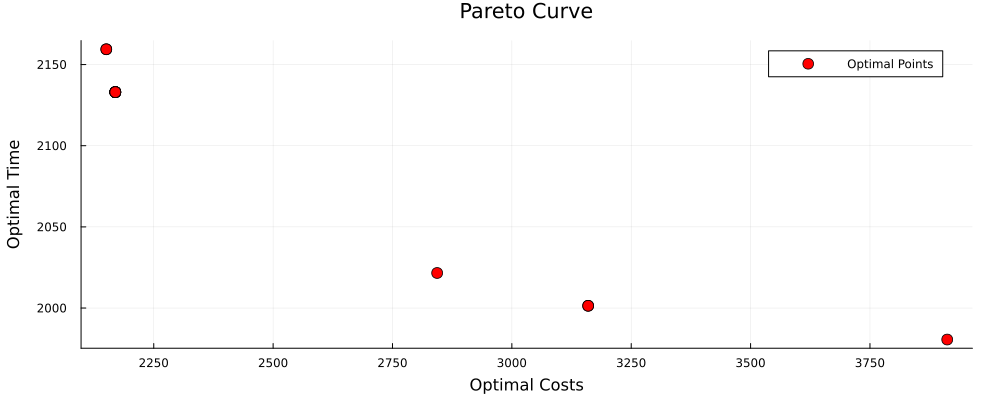

In [27]:
lambdas = sort([0, 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4., 4.5, 5., 10., 20., 25, 50]) # tradeoff parameter
opt_costs = []
opt_times = []

for lambda_time in lambdas
    # Model
    m = Model(Gurobi.Optimizer)

    
    # Variables
    @variable(m, x[arc in arcs, comp in components] >= 0, Int)   # flow of x component through arc
    @variable(m, r[node in nodes, comp in components] >= 0, Int) # r repairs of compponent at node

    
    # Constraints
    ## Flow Conservation
    for comp in components, node in nodes
        inflow  = sum(x[(node_from, node), comp] for node_from in incoming[node]) # flow of component into node
        outflow = sum(x[(node, node_to), comp] for node_to in outgoing[node])     # flow of component out of node
        demand = get(demands, (node, comp), Demand("", "", "", 0)).qty            # demand of component present at node
        stock = get(inventory, (node, comp), Stock("", "", 0)).qty                # initial stock of component at node
        repairs = r[node, comp]                                                   # repairs of component at node
        consumed = sum(qty * r[node, comp_repaired]                               # component consumed for repairs at node
                       for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
        @constraint(m, stock + inflow + repairs >= outflow + consumed + demand)
    end

    
    ## Cannot Repair into Part Components
    for comp in components
        if BOM[comp].comp_type == "part"
            for node in nodes
                @constraint(m, r[node, comp] == 0)
            end
        end
    end
    
    
    ## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
    for node in nodes, comp in components
        if BOM[comp].repair_difficulty > node_dict[node].repair_capability
            @constraint(m, r[node, comp] == 0)
        end
    end


    ## Limit Node Repairs to Repair Capacity Hours
    for node in nodes
        @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult *
                    BOM[comp].repair_time * r[node, comp] for comp in components) <= node_dict[node].repair_capacity)
    end
    

    
    # Objective
    @objective(m, Min,
               sum(arc_dict[arc].trans_cost * x[arc, comp]
               for comp in components, arc in arcs) + # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp]
               for comp in components, node in nodes) + # repair cost
               lambda_time * (sum(arc_dict[arc].trans_time * x[arc, comp]
               for comp in components, arc in arcs) + # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp]
               for comp in components, node in nodes)) # repair time
               )
    
    
    # Solve
    set_silent(m)
    optimize!(m)


    
    # Extract Values
    opt_cost = sum(arc_dict[arc].trans_cost * value(x[arc, comp])
               for comp in components, arc in arcs) + # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * value(r[node, comp])
               for comp in components, node in nodes) # repair cost
    opt_time = sum(arc_dict[arc].trans_time * value(x[arc, comp])
               for comp in components, arc in arcs) + # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * value(r[node, comp])
               for comp in components, node in nodes) # repair time
    push!(opt_costs, opt_cost)
    push!(opt_times, opt_time)
end



# Plot Pareto Curve
p = scatter(opt_costs, opt_times, marker=:circle, markersize=6, 
          label="Optimal Points", color=:red)
title!(p, "Pareto Curve")
xlabel!(p, "Optimal Costs")
ylabel!(p, "Optimal Time")


# Display
plot(p, size=(1000, 400), margin=5Plots.mm)

As shown in the figure above, there exist multiple optimal solutions depending on the weight we place on time. In the extreme case 




# Level 3 and Beyond
Level 3, we have the notion of time steps, where we can back order demand at a cost multiplier. 


Level 3 and beyond become more ambitious and include a variety of ideas that may or may not be feasible by the deadline. In no particular order:

### Math Model

We want to modify our Level 2 math model to include the extra logic of Level 3. Specifically, we want to take Level 2 and turn it into a multi-period planning problem; additionally, we want to allow for backlogging demands at an elivated cost in case repairs cannot be met on a given timestep.


We have the following additional problem data.

Let $\mathcal{T}$ denote the set of timesteps (e.g. days).



We first declare the following additional decision varaibles and decision variable modifications.

Let $s_{n, k, t} \in \mathbb{Z}$ denote the number of component $k \in K$ stored at node $n \in N$ at time $t \in \mathcal{T} \cup \{ 0 \}$ where $t = 0$ denotes the systems initial state;
let $b_{n, k, t} \in \mathbb{Z}$ denote the number of component $k \in K$ backordered at node $n \in N$ at time $t \in \mathcal{T} \cup \{ 0 \}$.
In addition, we append a time index $t \in \mathcal{T}$ for all transport and repair decision variables, $x_{a, k, t}$ and $r_{n, k, t}$.
Let $B$ denote a flat penalty cost to any backordersing.



We next construct the following additional constraints.

We cannot allow for negative stock nor negative backorders at backorders; thus, we have the nonnegativity constraints,
$$
s_{n, k, t} \geq 0, \qquad n \in N,\ k \in K,\ t \in \mathcal{T}
$$
$$
b_{n, k, t} \geq 0. \qquad n \in N,\ k \in K,\ t \in \mathcal{T}
$$

The initial stock at each node is the inventory,
$$
s_{n, k, 0} = I_{n, k}. \qquad n \in N,\ k \in K
$$

We do not start with any backorders and we must fulfull all backorders by the end of the timesteps $t^{\text{end}} \in \mathcal{T}$,
$$
b_{n, k, t} = 0. \qquad t \in \{ 0, t^{\text{end}} \}
$$

We must modify our flow constraint so that it applies over each timestep $t \in \mathcal{T}$ as well as properly balance the constraint using the stock over time timestep,
$$
s_{n, k, t - 1} + \sum_{(i, n) \in A} x_{(i, n), k, t} + r_{n, k, t} + b_{n, k, t} = s_{n, k, t} + \sum_{(n, i) \in A} x_{(n, i), k, t} + \sum_{k' \in K_{k}} r_{n, k', t}q_{k', k} + d_{n, k}, \qquad n \in N,\ k \in K,\ t \in \mathcal{T}
$$
which represents initial stock + inflow + repairs + backorders = final stock + outflow + consumed + demand.

In addition, we append the proper time index $t \in \mathcal{T}$ for all constraints from Level 2.



We lastly modify our objective function.

We additionally have a flat cost for any backorders,
$$
\sum_{n \in N,\ k \in K,\ t \in \mathcal{T}} Bb_{n, k, t};
$$
hence, we have the objective function we want to minimize as,
$$
\begin{align*}
    & \left( \sum_{a \in A, k \in K, t \in \mathcal{T}} C_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k, t} + \sum_{n \in N,\ k \in K,\ t \in \mathcal{T}} Bb_{n, k, t} \right) + \\
    \lambda^{\text{time}}&\left( \sum_{a \in A, k \in K, t \in \mathcal{T}} T_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k, t} \right)
\end{align*}
$$



Putting this together, we have the integer linear program,
$$
\begin{align*}
    \min \quad 
    & \left( \sum_{a \in A, k \in K, t \in \mathcal{T}} C_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k, t} + \sum_{n \in N,\ k \in K,\ t \in \mathcal{T}} Bb_{n, k, t} \right) + \\
\lambda^{\text{time}}&\left( \sum_{a \in A, k \in K, t \in \mathcal{T}} T_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k, t} \right) \\
    \text{s.t.} \quad
    & s_{n, k, t - 1} + \sum_{(i, n) \in A} x_{(i, n), k, t} + r_{n, k, t} + b_{n, k, t} = s_{n, k, t} + \sum_{(n, i) \in A} x_{(n, i), k, t} + \sum_{k' \in K_{k}} r_{n, k', t}q_{k', k} + d_{n, k},
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & r_{n, k, t} = 0,
        && n \in N \setminus N_{k},\ k \in K,\ t \in \mathcal{T} \\
    & \sum_{k \in K} m_{n}^{\text{time}} T_{k}^{\text{repair}} r_{n, k, t} \leq T_{n}^{\text{cap}},
        && n \in N,\ t \in \mathcal{T} \\
    & x_{a, k, t} \geq 0, 
        && a \in A,\ k \in K,\ t \in \mathcal{T} \\
    & r_{n, k, t} \geq 0, 
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & s_{n, k, t} \geq 0,
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & b_{n, k, t} \geq 0.
        && n \in N,\ k \in K,\ t \in \mathcal{T}
\end{align*}
$$

### Implementation

Similarly, we load in the Level 3 data.

In [86]:
# Load Data
node_df = CSV.read("level3data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level3data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level3data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level3data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level3data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level3data/component_multiplier.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
    repair_capacity::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    repair_capacity = df_node.repair_capacity
    node = Node(node_id, node_type, (x, y), repair_capability, repair_capacity)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
    trans_time::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    trans_time = df_arc.time_cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost, trans_time)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_difficulty::Int
    repair_cost::Float64
    repair_time::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_difficulty = bom_item.parent_component_repair_difficulty
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_time = bom_item.parent_component_repair_time
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_difficulty, comp_repair_cost, comp_repair_time, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    part_id = bom_item.child_component_id
    part_type = "part"
    part_repair_difficulty = 0
    part_repair_cost = 0
    part_repair_time = 0
    part_repair_list = []
    part = Component(part_id, part_type, part_repair_difficulty, part_repair_cost, part_repair_time, part_repair_list)
    BOM[part_id] = part
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
timesteps = 1
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    total_qty::Int
    time_schedule::Vector
end
demands = Dict() # dictionary of each node and component pair -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    total_qty = df_demand.quantity
    time_schedule = []
    for slice in names(df_demand, r"^time_slice_") 
        push!(time_schedule, df_demand[slice])
    end
    timesteps = length(time_schedule)
    demand = Demand(demand_id, demand_node, demand_comp, total_qty, time_schedule)
    demands[(demand_node, demand_comp)] = demand
end

# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of each node and component pair -> Stock struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
    repair_time_mult::Float64
end
mult_dict = Dict() # dictionary of each location and component -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier # change column name to repair_cost_mult
    repair_time_mult = df_mults.repair_time_multiplier # change column name to repair_time_mult
    mults = Mults(mults_node, mults_comp, repair_cost_mult, repair_time_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end

We then directly implement the Level 3.

In [87]:
# Parameters
lambda_time = 1 # tradeoff parameters
B = 500         # backorder penalty

# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components, timestep in 1:timesteps] >= 0, Int)   # flow x of component through arc
@variable(m, r[node in nodes, comp in components, timestep in 1:timesteps] >= 0, Int) # repair r of compponent at node
@variable(m, s[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # store s of component at node
@variable(m, b[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # backorder b of component at node

# Constraints
## Flow Conservation
for comp in components, node in nodes, timestep in 1:timesteps
    inflow  = sum(x[(node_from, node), comp, timestep]           # flow of component into node
                  for node_from in incoming[node])
    outflow = sum(x[(node, node_to), comp, timestep]             # flow of component out of node
                  for node_to in outgoing[node])
    demand = get(demands, (node, comp), Demand("", "", "", 0,    # demand of component present at node
                 zeros(Int, timesteps))).time_schedule[timestep] +
             b[node, comp, timestep - 1]                         # previos backorders
    backorders = b[node, comp, timestep]                         # backorders of component at node
    stock_initial = s[node, comp, timestep - 1]                  # initial stock of component at node
    stock_final = s[node, comp, timestep]                        # final stock of component at node
    repairs = r[node, comp, timestep]                            # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired, timestep]        # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock_initial + inflow + repairs + backorders == stock_final + outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes, timestep in 1:timesteps
            @constraint(m, r[node, comp, timestep] == 0)
        end
    end
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if BOM[comp].repair_difficulty > node_dict[node].repair_capability
        for timestep in 1:timesteps
            @constraint(m, r[node, comp, timestep] == 0)
        end
    end
end


## Limit Node Repairs to Repair Capacity Hours
for node in nodes, timestep in 1:timesteps
    @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time *
                r[node, comp, timestep] for comp in components) <= node_dict[node].repair_capacity)
end


## Initial Storage is Inventory
for node in nodes, comp in components
     @constraint(m, s[node, comp, 0] == get(inventory, (node, comp), Stock("", "", 0)).qty)
end


## Backorders Must be Fulfilled
for node in nodes, comp in components, timestep in [0, timesteps]
     @constraint(m, b[node, comp, timestep] == 0)
end



# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * x[arc, comp, timestep]
           for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport cost
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps) +  # repair cost
           sum(B * b[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps) +  # backorder cost
           lambda_time * (sum(arc_dict[arc].trans_time * x[arc, comp, timestep]
           for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport time
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps)) # repair time
           )


# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


In [88]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(timestep = Int[], comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs, timestep in 1:timesteps
    val = value(x[(node_from, node_to), comp, timestep])
    if val > 1e-3
        push!(flow_output_df, (timestep = timestep, comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:timestep, :comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(timestep = Int[], comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes, timestep in 1:timesteps
    val = value(r[node, comp, timestep])
    if val > 1e-3
        push!(repair_output_df, (timestep = timestep, comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:timestep, :comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)
println()

## Backorder Output
backorder_output_df = DataFrame(timestep = Int[], comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes, timestep in 1:timesteps
    val = value(b[node, comp, timestep])
    if val > 1e-3
        push!(backorder_output_df, (timestep = timestep, comp_id = comp, node_id = node, qty = val))
    end
end
sort!(backorder_output_df, [:timestep, :comp_id, :node_id,])
println("Optimal Backorder Schedule:")
println(backorder_output_df)


## Convert Output to CSV
CSV.write("level3output/flow_output.csv", flow_output_df)
CSV.write("level3output/repair_output.csv", repair_output_df)
CSV.write("level3output/backorder_output.csv", backorder_output_df);

Optimal Objective Value: 3901.0

Optimal Flow Schedule:
33×5 DataFrame
 Row │ timestep  comp_id  node_from  node_to  qty   
     │ Int64     String   String     String   Int64 
─────┼──────────────────────────────────────────────
   1 │        1  LRU_2    DEPOT_1    REGWH_1      1
   2 │        1  LRU_2    DEPOT_1    REGWH_2      2
   3 │        1  LRU_2    LOCAL_1    CUST_2       1
   4 │        1  LRU_2    LOCAL_3    CUST_3       2
   5 │        1  LRU_2    LOCAL_4    CUST_4       1
   6 │        1  LRU_2    REGWH_1    LOCAL_1      1
   7 │        1  LRU_2    REGWH_2    LOCAL_3      2
   8 │        1  LRU_2    REGWH_2    LOCAL_4      1
   9 │        1  LRU_2    SPEC_2     DEPOT_1      2
  10 │        1  LRU_2    SPEC_4     REGWH_2      1
  11 │        1  LRU_2_2  DEPOT_1    SPEC_2       2
  12 │        1  LRU_2_2  REGWH_2    SPEC_4       1
  13 │        1  LRU_5    DEPOT_1    REGWH_1      1
  14 │        1  LRU_5    LOCAL_1    CUST_1       1
  15 │        1  LRU_5    REGWH_1    LOCAL

## Pareto Curve Construction

Pareto curve between cost and time.

In [31]:
lambdas = sort([0, 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4., 4.5, 5.]) # tradeoff parameter
opt_costs = []
opt_times = [];

In [32]:
# Parameters
B = 500 # backorder penalty

for lambda_time in lambdas
    # Model
    m = Model(Gurobi.Optimizer)
    
    
    # Variables
    @variable(m, x[arc in arcs, comp in components, timestep in 1:timesteps] >= 0, Int)   # flow x of component through arc
    @variable(m, r[node in nodes, comp in components, timestep in 1:timesteps] >= 0, Int) # repair r of compponent at node
    @variable(m, s[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # store s of component at node
    @variable(m, b[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # backorder b of component at node
    
    # Constraints
    ## Flow Conservation
    for comp in components, node in nodes, timestep in 1:timesteps
        inflow  = sum(x[(node_from, node), comp, timestep]           # flow of component into node
                      for node_from in incoming[node])
        outflow = sum(x[(node, node_to), comp, timestep]             # flow of component out of node
                      for node_to in outgoing[node])
        demand = get(demands, (node, comp), Demand("", "", "", 0,    # demand of component present at node
                     zeros(Int, timesteps))).time_schedule[timestep] +
                 b[node, comp, timestep - 1]                         # previos backorders
        backorders = b[node, comp, timestep]                         # backorders of component at node
        stock_initial = s[node, comp, timestep - 1]                  # initial stock of component at node
        stock_final = s[node, comp, timestep]                        # final stock of component at node
        repairs = r[node, comp, timestep]                            # repairs of component at node
        consumed = sum(qty * r[node, comp_repaired, timestep]        # component consumed for repairs at node
                       for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
        @constraint(m, stock_initial + inflow + repairs + backorders == stock_final + outflow + consumed + demand)
    end
    
    
    ## Cannot Repair into Part Components
    for comp in components
        if BOM[comp].comp_type == "part"
            for node in nodes, timestep in 1:timesteps
                @constraint(m, r[node, comp, timestep] == 0)
            end
        end
    end
    
    
    ## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
    for node in nodes, comp in components
        if BOM[comp].repair_difficulty > node_dict[node].repair_capability
            for timestep in 1:timesteps
                @constraint(m, r[node, comp, timestep] == 0)
            end
        end
    end

    ## Limit Node Repairs to Repair Capacity Hours
    for node in nodes, timestep in 1:timesteps
        @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time *
                    r[node, comp, timestep] for comp in components) <= node_dict[node].repair_capacity)
    end
    
    
    ## Initial Storage is Inventory
    for node in nodes, comp in components
         @constraint(m, s[node, comp, 0] == get(inventory, (node, comp), Stock("", "", 0)).qty)
    end
    
    
    ## Backorders Must be Fulfilled
    for node in nodes, comp in components, timestep in [0, timesteps]
         @constraint(m, b[node, comp, timestep] == 0)
    end
    

    
    # Objective
    @objective(m, Min,
               sum(arc_dict[arc].trans_cost * x[arc, comp, timestep]
               for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps) +  # repair cost
               sum(B * b[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps) +  # backorder cost
               lambda_time * (sum(arc_dict[arc].trans_time * x[arc, comp, timestep]
               for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps)) # repair time
               )
    

    
    # Solve
    set_silent(m)
    optimize!(m)


    
    # Extract Values
    opt_cost = sum(arc_dict[arc].trans_cost * value(x[arc, comp, timestep])
               for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport cost
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * value(r[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps) +  # repair cost
               sum(B * value(b[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps)    # backorder cost
    opt_time = sum(arc_dict[arc].trans_time * value(x[arc, comp, timestep])
               for comp in components, arc in arcs, timestep in 1:timesteps) +    # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * value(r[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps)    # repair time
    push!(opt_costs, opt_cost)
    push!(opt_times, opt_time)
end

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic lic

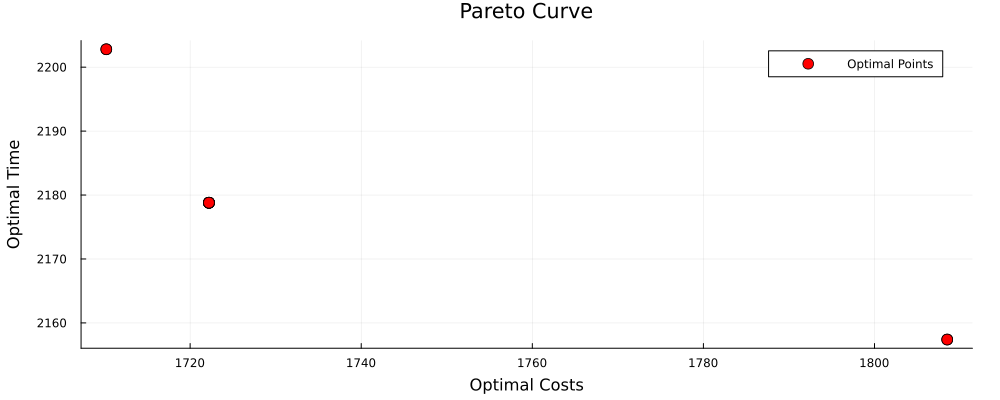

In [33]:
# Plot Pareto Curve
p = scatter(opt_costs, opt_times, marker=:circle, markersize=6, 
             label="Optimal Points", color=:red)
title!(p, "Pareto Curve")
xlabel!(p, "Optimal Costs")
ylabel!(p, "Optimal Time")


# Display
plot(p, size=(1000, 400), margin=5Plots.mm)

# 3.5 
instead of having to ship all items indivually, we will use binary variables to reprsenent if we decide to actually ship over that edge, and we do it in one batch.

### Math Model

We want to modify our Level 3 math model to include the alternate logic of Level 3.5. Specifically, want to convert the transportation cost and time logic so that, for each timestep, we bulk transport components along nodes with a large initial cost/time penalty and then marginal cost increases with components transported.


We have the following additional problem data.

Let $\mathcal{T}$ denote the set of timesteps (e.g. days).

Let $R \geq 0$ denote the marginal transport cost of transporting components over the arc relative to the arcs cost; e.g. $C = \tfrac{1}{10}$ means moving one additional component along the arc has a cost of $\tfrac{1}{10}$ of the standard transport cost;
let $M$ be solve large parameter such that the following $y_{a, t}$ binary decision variables enact the desired fixed cost. 


We first declare the following additional decision varaibles and decision variable modifications.

Let $y_{a, t} \in \{ 0, 1 \}$ denote if any $x_{a, k, t} > 0$ over $k \in K$.



We next construct the following additional constraints.

We want $x_{a, k, t} > 0$ only if $y_{a, t} = 1$ for any $k \in K$,
$$
x_{a, k, t} \leq My_{a, t}. \qquad a \in A,\ k \in K,\ t \in \mathcal{T}
$$



We lastly modify our objective function.

We want to make transportation cost be a fixed cost if any components are transported across a given arc,
$$
\sum_{a \in A, t \in \mathcal{T}} C_{a}^{flow} y_{a, t},
$$
and also a marginal cost for each additional component transported across the arc,
$$
\sum_{a \in A, k \in K, t \in \mathcal{T}} RC_{a}^{flow} x_{a, k, t};
$$
thus, we have our full cost objective,
$$
\sum_{a \in A, t \in \mathcal{T}} C_{a}^{flow} y_{a, t} + \sum_{a \in A, k \in K, t \in \mathcal{T}} RC_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k, t} + \sum_{n \in N,\ k \in K,\ t \in \mathcal{T}} Bb_{n, k, t}.
$$
We want to make transportation time be a fixed time if any components are transported across a given arc,
$$
\sum_{a \in A, t \in \mathcal{T}} C_{a}^{flow} y_{a, t};
$$
thus, we have our full time objective,
$$
\sum_{a \in A, t \in \mathcal{T}} T_{a}^{flow} y_{a, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k, t}
$$


Putting this together, we have the integer linear program,
$$
\begin{align*}
    \min \quad 
    & \left( \sum_{a \in A, t \in \mathcal{T}} C_{a}^{flow} y_{a, t} + \sum_{a \in A, k \in K, t \in \mathcal{T}} RC_{a}^{flow} x_{a, k, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{cost}}C_{k}^{repair} r_{n, k, t} + \sum_{n \in N,\ k \in K,\ t \in \mathcal{T}} Bb_{n, k, t} \right) + \\
\lambda^{\text{time}}&\left( \sum_{a \in A, t \in \mathcal{T}} T_{a}^{flow} y_{a, t} + \sum_{n \in N, k \in K, t \in \mathcal{T}} m_{n}^{\text{time}} T_{k}^{repair} r_{n, k, t} \right) \\
    \text{s.t.} \quad
    & s_{n, k, t - 1} + \sum_{(i, n) \in A} x_{(i, n), k, t} + r_{n, k, t} + b_{n, k, t} = s_{n, k, t} + \sum_{(n, i) \in A} x_{(n, i), k, t} + \sum_{k' \in K_{k}} r_{n, k', t}q_{k', k} + d_{n, k},
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & r_{n, k, t} = 0,
        && n \in N \setminus N_{k},\ k \in K,\ t \in \mathcal{T} \\
    & \sum_{k \in K} m_{n}^{\text{time}} T_{k}^{\text{repair}} r_{n, k, t} \leq T_{n}^{\text{cap}},
        && n \in N,\ t \in \mathcal{T} \\
    & x_{a, k, t} \leq My_{a, t},
        && a \in A,\ k \in K,\ t \in \mathcal{T} \\
    & x_{a, k, t} \geq 0, 
        && a \in A,\ k \in K,\ t \in \mathcal{T} \\
    & r_{n, k, t} \geq 0, 
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & s_{n, k, t} \geq 0,
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & b_{n, k, t} \geq 0,
        && n \in N,\ k \in K,\ t \in \mathcal{T} \\
    & y_{a, t} \in \{ 0, 1 \}.
        && a \in A,\ t \in \mathcal{T}
\end{align*}
$$

### Implementation

We reload in the Level 3 data.

In [101]:
# Load Data
node_df = CSV.read("level3data/nodes.csv", DataFrame,delim=',')
arc_df = CSV.read("level3data/arcs.csv", DataFrame,delim=',')
bom_df = CSV.read("level3data/bom.csv", DataFrame,delim=',')
demand_df = CSV.read("level3data/demand.csv", DataFrame,delim=',')
node_inv_df = CSV.read("level3data/node_inventory.csv", DataFrame,delim=',')
mult_df = CSV.read("level3data/component_multiplier.csv", DataFrame,delim=',')


# Convert node_df to Node Information
#--------------------------------------------------
struct Node # Node struct
    name::String
    node_type::String
    loc::Tuple{Float64, Float64}
    repair_capability::Int
    repair_capacity::Int
end
node_dict = Dict() # dictionary of nodes -> Node struct
for df_node in eachrow(node_df) # add nodes to node_dict
    node_id = df_node.node_id
    node_type = df_node.node_type
    (x, y) = (df_node.x, df_node.y)
    repair_capability = df_node.repair_capability
    repair_capacity = df_node.repair_capacity
    node = Node(node_id, node_type, (x, y), repair_capability, repair_capacity)
    node_dict[node_id] = node
end
nodes = collect(keys(node_dict)) # list of nodes


# Convert arc_df to Arc Information
#--------------------------------------------------
struct Arc # Arc struct
    name::String
    fromto::Tuple{String, String}
    trans_cost::Float64
    trans_time::Float64
end
arc_dict = Dict() # dictionary of arcs -> Arc struct
for df_arc in eachrow(arc_df) # add arcs to arc_dict
    arc_id = df_arc.arc_id
    node_from = df_arc.from_node
    node_to = df_arc.to_node
    trans_cost = df_arc.cost
    trans_time = df_arc.time_cost
    arc = Arc(arc_id, (node_from, node_to), trans_cost, trans_time)
    arc_dict[(node_from, node_to)] = arc
end
arcs = collect(keys(arc_dict)) # list of arcs of network
incoming = Dict() # dictionary of node -> nodes incident to the node
outgoing = Dict() # dictionary of node -> nodes incident from the node
for (node_from, node_to) in arcs # add nodes to incoming and outgoing
    push!(get!(incoming, node_to, []), node_from)
    push!(get!(outgoing, node_from, []), node_to)
end


# Convert bom_df to Bill of Material (BOM) Information
#--------------------------------------------------
struct Component # Component struct
    comp_id::String
    comp_type::String
    repair_difficulty::Int
    repair_cost::Float64
    repair_time::Float64
    subcomps::Vector{Tuple{String, Int}}
end
BOM = Dict() # dictionary of component -> Component struct
for bom_item in eachrow(bom_df) # build dictionary
    comp_id = bom_item.parent_component_id
    comp_type = bom_item.parent_component_class
    comp_repair_difficulty = bom_item.parent_component_repair_difficulty
    comp_repair_cost = bom_item.parent_component_cost
    comp_repair_time = bom_item.parent_component_repair_time
    comp_repair_list = []
    sub_bom = subset(bom_df, :parent_component_id => ByRow(==(comp_id)))
    for sub_comp in eachrow(sub_bom)
        sub_comp_id = sub_comp.child_component_id
        sub_comp_qty = sub_comp.quantity_required
        push!(comp_repair_list, (sub_comp_id, sub_comp_qty))
    end
    comp = Component(comp_id, comp_type, comp_repair_difficulty, comp_repair_cost, comp_repair_time, comp_repair_list)
    BOM[comp_id] = comp
end
part_bom = subset(bom_df, :child_component_class => ByRow(==("part"))) # add parts components to BOM
for bom_item in eachrow(part_bom)
    part_id = bom_item.child_component_id
    part_type = "part"
    part_repair_difficulty = 0
    part_repair_cost = 0
    part_repair_time = 0
    part_repair_list = []
    part = Component(part_id, part_type, part_repair_difficulty, part_repair_cost, part_repair_time, part_repair_list)
    BOM[part_id] = part
end
components = collect(keys(BOM)) # list of components in BOM
subcomp_dict = Dict() # dictionary of comonents -> list of subcomponents
for comp in components
    subcomp_bom = subset(bom_df, :child_component_id => ByRow(==(comp)))
    subcomp_for_lst = []
    for subcomp_for in eachrow(subcomp_bom)
        push!(subcomp_for_lst, (subcomp_for.parent_component_id, subcomp_for.quantity_required))
    end
    subcomp_dict[comp] = subcomp_for_lst
end


# Convert demand_df to Demand Information
#--------------------------------------------------
timesteps = 1
struct Demand # Demand struct
    name::String
    loc::String
    component::String
    total_qty::Int
    time_schedule::Vector
end
demands = Dict() # dictionary of each node and component pair -> Demand struct
for df_demand in eachrow(demand_df) # build dictionary
    demand_id = df_demand.demand_id
    demand_node = df_demand.node_id
    demand_comp = df_demand.component_id
    total_qty = df_demand.quantity
    time_schedule = []
    for slice in names(df_demand, r"^time_slice_") 
        push!(time_schedule, df_demand[slice])
    end
    timesteps = length(time_schedule)
    demand = Demand(demand_id, demand_node, demand_comp, total_qty, time_schedule)
    demands[(demand_node, demand_comp)] = demand
end

# Convert node_inv_df to Node Inventory Information
#--------------------------------------------------
struct Stock # Stock struct
    loc::String
    component::String
    qty::Int
end
inventory = Dict() # dictionary of each node and component pair -> Stock struct
for df_stock in eachrow(node_inv_df) # build dictionary
    stock_node = df_stock.node_id
    stock_comp = df_stock.component_id
    qty = df_stock.quantity
    stock = Stock(stock_node, stock_comp, qty)
    inventory[(stock_node, stock_comp)] = stock
end
M = sum(node_inv_df.quantity) # generate Big-M for Flow


# Convert comp_mult_df to Component Multiplier Information
#--------------------------------------------------
struct Mults # Mult struct
    loc::String
    component::String
    repair_cost_mult::Float64
    repair_time_mult::Float64
end
mult_dict = Dict() # dictionary of each location and component -> Comp_Mult struct
for df_mults in eachrow(mult_df) # build dictionary
    mults_node = df_mults.node_id
    mults_comp = df_mults.component_id
    repair_cost_mult = df_mults.repair_cost_multiplier # change column name to repair_cost_mult
    repair_time_mult = df_mults.repair_time_multiplier # change column name to repair_time_mult
    mults = Mults(mults_node, mults_comp, repair_cost_mult, repair_time_mult)
    mult_dict[(mults_node, mults_comp)] = mults
end

We then directly implement the Level 3.5.

In [102]:
# Parameters
lambda_time = 1 # tradeoff parameters
B = 500         # backorder penalty
R = 1 / 10      # marginal transport price ratio

# Model
m = Model(Gurobi.Optimizer)


# Variables
@variable(m, x[arc in arcs, comp in components, timestep in 1:timesteps] >= 0, Int)   # flow x of component through arc
@variable(m, y[arc in arcs, timestep in 1:timesteps], Bin)                            # y gives if flow through arc
@variable(m, r[node in nodes, comp in components, timestep in 1:timesteps] >= 0, Int) # repair r of compponent at node
@variable(m, s[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # store s of component at node
@variable(m, b[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # backorder b of component at node

# Constraints
## Flow Conservation
for comp in components, node in nodes, timestep in 1:timesteps
    inflow  = sum(x[(node_from, node), comp, timestep]           # flow of component into node
                  for node_from in incoming[node])
    outflow = sum(x[(node, node_to), comp, timestep]             # flow of component out of node
                  for node_to in outgoing[node])
    demand = get(demands, (node, comp), Demand("", "", "", 0,    # demand of component present at node
                 zeros(Int, timesteps))).time_schedule[timestep] +
             b[node, comp, timestep - 1]                         # previos backorders
    backorders = b[node, comp, timestep]                         # backorders of component at node
    stock_initial = s[node, comp, timestep - 1]                  # initial stock of component at node
    stock_final = s[node, comp, timestep]                        # final stock of component at node
    repairs = r[node, comp, timestep]                            # repairs of component at node
    consumed = sum(qty * r[node, comp_repaired, timestep]        # component consumed for repairs at node
                   for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
    @constraint(m, stock_initial + inflow + repairs + backorders == stock_final + outflow + consumed + demand)
end


## Cannot Repair into Part Components
for comp in components
    if BOM[comp].comp_type == "part"
        for node in nodes, timestep in 1:timesteps
            @constraint(m, r[node, comp, timestep] == 0)
        end
    end
end


## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
for node in nodes, comp in components
    if BOM[comp].repair_difficulty > node_dict[node].repair_capability
        for timestep in 1:timesteps
            @constraint(m, r[node, comp, timestep] == 0)
        end
    end
end


## Limit Node Repairs to Repair Capacity Hours
for node in nodes, timestep in 1:timesteps
    @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time *
                r[node, comp, timestep] for comp in components) <= node_dict[node].repair_capacity)
end


## Initial Storage is Inventory
for node in nodes, comp in components
     @constraint(m, s[node, comp, 0] == get(inventory, (node, comp), Stock("", "", 0)).qty)
end


## Backorders Must be Fulfilled
for node in nodes, comp in components, timestep in [0, timesteps]
     @constraint(m, b[node, comp, timestep] == 0)
end


## Transport Decision y Constraint
for arc in arcs, comp in components, timestep in 1:timesteps
     @constraint(m, x[arc, comp, timestep] <= M * y[arc, timestep])
end



# Objective
@objective(m, Min,
           sum(arc_dict[arc].trans_cost * y[arc, timestep]
           for arc in arcs, timestep in 1:timesteps) +                       # transport cost base
           sum(R * arc_dict[arc].trans_cost * x[arc, comp, timestep]
           for arc in arcs, comp in components, timestep in 1:timesteps) +   # transport cost marginal
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps) + # repair cost
           sum(B * b[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps) + # backorder cost
           lambda_time * (sum(arc_dict[arc].trans_time * y[arc, timestep]
           for arc in arcs, timestep in 1:timesteps) +                       # transport time
           sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp, timestep]
           for comp in components, node in nodes, timestep in 1:timesteps))  # repair time
           )



# Solve
set_silent(m)
optimize!(m)

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13


In [103]:
# Output
println("Optimal Objective Value: ", round(objective_value(m), digits=2))
println()


## Flow Output
flow_output_df = DataFrame(timestep = Int[], comp_id = String[], node_from = String[], node_to = String[], qty = Int[])
for comp in components, (node_from, node_to) in arcs, timestep in 1:timesteps
    val = value(x[(node_from, node_to), comp, timestep])
    if val > 1e-3
        push!(flow_output_df, (timestep = timestep, comp_id = comp, node_from = node_from, node_to = node_to, qty = val))
    end
end
sort!(flow_output_df, [:timestep, :comp_id, :node_from, :node_to])
println("Optimal Flow Schedule:")
println(flow_output_df)
println()


## Repair Output
repair_output_df = DataFrame(timestep = Int[], comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes, timestep in 1:timesteps
    val = value(r[node, comp, timestep])
    if val > 1e-3
        push!(repair_output_df, (timestep = timestep, comp_id = comp, node_id = node, qty = val))
    end
end
sort!(repair_output_df, [:timestep, :comp_id, :node_id,])
println("Optimal Repair Schedule:")
println(repair_output_df)
println()


## Backorder Output
backorder_output_df = DataFrame(timestep = Int[], comp_id = String[], node_id = String[], qty = Int[])
for comp in components, node in nodes, timestep in 1:timesteps
    val = value(b[node, comp, timestep])
    if val > 1e-3
        push!(backorder_output_df, (timestep = timestep, comp_id = comp, node_id = node, qty = val))
    end
end
sort!(backorder_output_df, [:timestep, :comp_id, :node_id,])
println("Optimal Backorder Schedule:")
println(backorder_output_df)


## Convert Output to CSV
CSV.write("level3_5output/flow_output.csv", flow_output_df)
CSV.write("level3_5output/repair_output.csv", repair_output_df)
CSV.write("level3_5output/backorder_output.csv", backorder_output_df);

Optimal Objective Value: 2152.8

Optimal Flow Schedule:
20×5 DataFrame
 Row │ timestep  comp_id  node_from  node_to  qty   
     │ Int64     String   String     String   Int64 
─────┼──────────────────────────────────────────────
   1 │        1  LRU_2    CUST_3     LOCAL_3      1
   2 │        1  LRU_2    DEPOT_1    SPEC_1       1
   3 │        1  LRU_2    LOCAL_2    CUST_2       2
   4 │        1  LRU_2    LOCAL_2    CUST_3       4
   5 │        1  LRU_2    LOCAL_3    CUST_4       1
   6 │        1  LRU_2    REGWH_1    LOCAL_2      6
   7 │        1  LRU_2    SPEC_1     REGWH_1      6
   8 │        1  LRU_2_1  DEPOT_1    SPEC_1       4
   9 │        1  LRU_2_2  DEPOT_1    SPEC_1       5
  10 │        1  LRU_3    DEPOT_1    SPEC_1       2
  11 │        1  LRU_3    LOCAL_2    CUST_3       2
  12 │        1  LRU_3    REGWH_1    LOCAL_2      2
  13 │        1  LRU_3    SPEC_1     REGWH_1      2
  14 │        1  LRU_5    DEPOT_1    SPEC_1       3
  15 │        1  LRU_5    LOCAL_2    CUST_

In [73]:
lambdas = sort([0, 0.5, 1., 1.5, 2., 2.5, 3., 3.5, 4., 4.5, 5.]) # tradeoff parameter
opt_costs = []
opt_times = [];

In [74]:
# Parameters
B = 500 # backorder penalty
R = 1 / 10      # marginal transport price ratio

for lambda_time in lambdas
    # Model
    m = Model(Gurobi.Optimizer)
    
    
    # Variables
    @variable(m, x[arc in arcs, comp in components, timestep in 1:timesteps] >= 0, Int)   # flow x of component through arc
    @variable(m, y[arc in arcs, timestep in 1:timesteps], Bin)                            # y gives if flow through arc
    @variable(m, r[node in nodes, comp in components, timestep in 1:timesteps] >= 0, Int) # repair r of compponent at node
    @variable(m, s[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # store s of component at node
    @variable(m, b[node in nodes, comp in components, timestep in 0:timesteps] >= 0, Int) # backorder b of component at node
    
    # Constraints
    ## Flow Conservation
    for comp in components, node in nodes, timestep in 1:timesteps
        inflow  = sum(x[(node_from, node), comp, timestep]           # flow of component into node
                      for node_from in incoming[node])
        outflow = sum(x[(node, node_to), comp, timestep]             # flow of component out of node
                      for node_to in outgoing[node])
        demand = get(demands, (node, comp), Demand("", "", "", 0,    # demand of component present at node
                     zeros(Int, timesteps))).time_schedule[timestep] +
                 b[node, comp, timestep - 1]                         # previos backorders
        backorders = b[node, comp, timestep]                         # backorders of component at node
        stock_initial = s[node, comp, timestep - 1]                  # initial stock of component at node
        stock_final = s[node, comp, timestep]                        # final stock of component at node
        repairs = r[node, comp, timestep]                            # repairs of component at node
        consumed = sum(qty * r[node, comp_repaired, timestep]        # component consumed for repairs at node
                       for (comp_repaired, qty) in subcomp_dict[comp]; init=0)
        @constraint(m, stock_initial + inflow + repairs + backorders == stock_final + outflow + consumed + demand)
    end
    
    
    ## Cannot Repair into Part Components
    for comp in components
        if BOM[comp].comp_type == "part"
            for node in nodes, timestep in 1:timesteps
                @constraint(m, r[node, comp, timestep] == 0)
            end
        end
    end
    
    
    ## Cannot Complete Repairs of Difficulty at Nodes with Insufficient Repair Capability
    for node in nodes, comp in components
        if BOM[comp].repair_difficulty > node_dict[node].repair_capability
            for timestep in 1:timesteps
                @constraint(m, r[node, comp, timestep] == 0)
            end
        end
    end


    ## Limit Node Repairs to Repair Capacity Hours
    for node in nodes, timestep in 1:timesteps
        @constraint(m, sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time *
                    r[node, comp, timestep] for comp in components) <= node_dict[node].repair_capacity)
    end
    
    
    ## Initial Storage is Inventory
    for node in nodes, comp in components
         @constraint(m, s[node, comp, 0] == get(inventory, (node, comp), Stock("", "", 0)).qty)
    end

    
    ## Backorders Must be Fulfilled
    for node in nodes, comp in components, timestep in [0, timesteps]
         @constraint(m, b[node, comp, timestep] == 0)
    end


    ## Transport Decision y Constraint
    for arc in arcs, comp in components, timestep in 1:timesteps
         @constraint(m, x[arc, comp, timestep] <= M * y[arc, timestep])
    end
    

    
    # Objective
    @objective(m, Min,
               sum(arc_dict[arc].trans_cost * y[arc, timestep]
               for arc in arcs, timestep in 1:timesteps) +                       # transport cost base
               sum(R * arc_dict[arc].trans_cost * x[arc, comp, timestep]
               for arc in arcs, comp in components, timestep in 1:timesteps) +   # transport cost marginal
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * r[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps) + # repair cost
               sum(B * b[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps) + # backorder cost
               lambda_time * (sum(arc_dict[arc].trans_time * y[arc, timestep]
               for arc in arcs, timestep in 1:timesteps) +                       # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * r[node, comp, timestep]
               for comp in components, node in nodes, timestep in 1:timesteps))  # repair time
               )
    

    
    # Solve
    set_silent(m)
    optimize!(m)


    
    # Extract Values
    opt_cost = sum(arc_dict[arc].trans_cost * value(y[arc, timestep])
               for arc in arcs, timestep in 1:timesteps) +                       # transport cost base
               sum(R * arc_dict[arc].trans_cost * value(x[arc, comp, timestep])
               for arc in arcs, comp in components, timestep in 1:timesteps) +   # transport cost marginal
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_cost_mult * BOM[comp].repair_cost * value(r[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps) +  # repair cost
               sum(B * value(b[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps)    # backorder cost
    opt_time = sum(arc_dict[arc].trans_time * value(y[arc, timestep])
               for arc in arcs, timestep in 1:timesteps) +    # transport time
               sum(get(mult_dict, (node, comp), Mults("", "", 1., 1.)).repair_time_mult * BOM[comp].repair_time * value(r[node, comp, timestep])
               for comp in components, node in nodes, timestep in 1:timesteps)    # repair time
    push!(opt_costs, opt_cost)
    push!(opt_times, opt_time)
end

Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic license - for non-commercial use only - expires 2027-04-13
Set parameter Username
Set parameter LicenseID to value 2806715
Academic lic

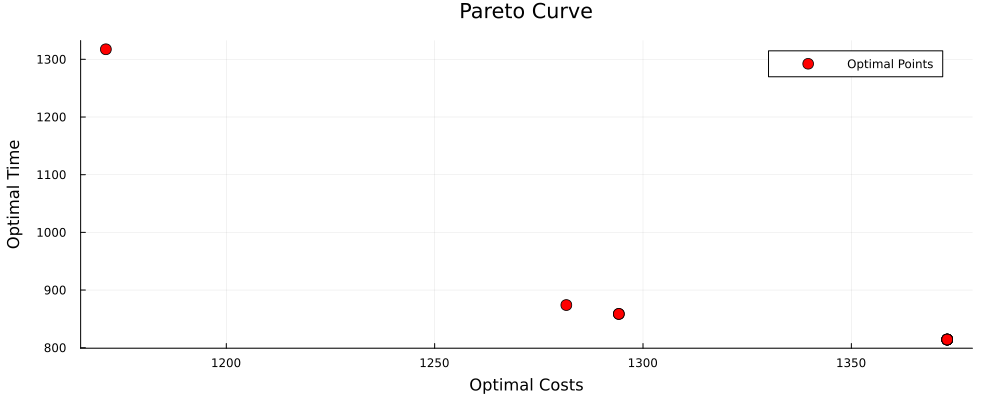

In [75]:
# Plot Pareto Curve
p = scatter(opt_costs, opt_times, marker=:circle, markersize=6, 
             label="Optimal Points", color=:red)
title!(p, "Pareto Curve")
xlabel!(p, "Optimal Costs")
ylabel!(p, "Optimal Time")


# Display
plot(p, size=(1000, 400), margin=5Plots.mm)

---
# <center>Conclusion</center>

[Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project. Be specific enough with your follow-up idea to show that you have given it some thought and that you think it’s actually doable!]

---
# <center>Citations</center>

1. Sherbrooke, C. C. (2004). *Optimal inventory modeling of systems* (2nd ed.). Kluwer Academic. (International Series in Operations Research & Management Science).
2. Gurobi Optimization, LLC. *Gurobi Optimizer Reference Manual*. 2026. https://www.gurobi.com (accessed April 29, 2026).

[Notice that AI, such as ChatGPT, was utilized in the debugging of some of the above code.]